In [1]:
import pandas as pd 
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,accuracy_score, precision_score, recall_score, f1_score,fbeta_score, roc_curve, roc_auc_score, precision_recall_curve,auc, average_precision_score, classification_report

In [2]:
pip install torchvision

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os

import tqdm


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from skimage import io
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.transforms import v2
from torch.utils.data import DataLoader, Dataset

In [4]:
directory = "C:\\Users\\User\\Documents\\ДЗ\\NA_Fish_Dataset"

In [5]:
labels = os.listdir(directory)

In [6]:
labels

['Black Sea Sprat',
 'Gilt Head Bream',
 'Horse Mackerel',
 'Red Mullet',
 'Red Sea Bream',
 'Sea Bass',
 'Shrimp',
 'Striped Red Mullet',
 'Trout']

In [7]:
image_paths = []
target = []
for fish_type in labels:
    for file in os.listdir(os.path.join(directory, fish_type)):
        image_paths.append(os.path.join(directory, fish_type, file))
        target.append(fish_type)

In [8]:
df = pd.DataFrame({'img' : image_paths, 'target' : target})
df.head()

,img,target
0,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
1,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
2,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
3,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
4,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat


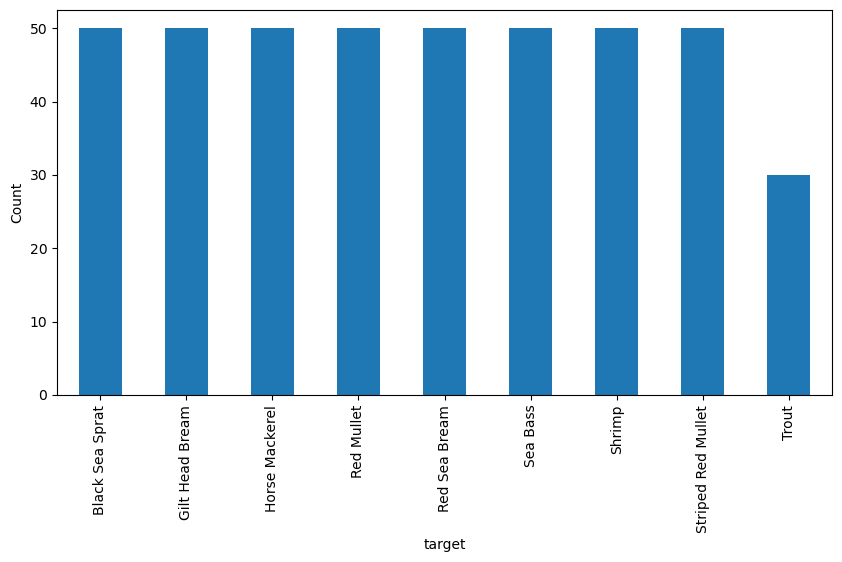

In [9]:
plt.figure(figsize=(10, 5))
df['target'].value_counts().plot(kind='bar')
plt.ylabel('Count')
plt.show()

In [10]:
indices_to_drop = df[~df['target'].isin(['Black Sea Sprat', 'Gilt Head Bream'])].index
df = df.drop(indices_to_drop)

In [11]:
df

,img,target
0,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
1,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
2,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
3,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
4,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
...,...,...
95,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gil...,Gilt Head Bream
96,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gil...,Gilt Head Bream
97,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gil...,Gilt Head Bream
98,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gil...,Gilt Head Bream


In [12]:
pip install timm torch torchvision pillow scikit-learn seaborn matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [13]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['target']
)

In [30]:
classes_list = sorted(df['target'].unique()) ## список уникальных названий видов рыб
class_to_idx = {name: i for i, name in enumerate(classes_list)} ##словарь название вида рыбы → числовой индекс 
num_classes = len(classes_list)

train_df['label_idx'] = train_df['target'].apply(lambda x: class_to_idx[x]) ##числовые метки
test_df['label_idx'] = test_df['target'].apply(lambda x: class_to_idx[x])

In [31]:
train_df

,img,target,label_idx
15,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat,0
52,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gil...,Gilt Head Bream,1
60,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gil...,Gilt Head Bream,1
66,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gil...,Gilt Head Bream,1
68,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gil...,Gilt Head Bream,1
...,...,...,...
17,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat,0
36,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat,0
85,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gil...,Gilt Head Bream,1
21,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat,0


In [19]:
import tensorflow as tf
IMG_SIZE = 224
BATCH_SIZE = 32

def load_image_and_label(path, label): ##читает файл, декодирует картинку, меняет размер и нормализует значения пикселей в диапазон [0, 1] делением на 255.
    img = tf.io.read_file(path) ##читает файл как байты.
    img = tf.image.decode_image(img, channels=3, expand_animations=False) ## превращает байты в картинку (3 канала: RGB)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE]) ##делает картинку нужного размера
    img = tf.cast(img, tf.float32) / 255.0
    return img, label
    
train_ds = tf.data.Dataset.from_tensor_slices((train_df['img'].values, train_df['label_idx'].values))
test_ds = tf.data.Dataset.from_tensor_slices((test_df['img'].values, test_df['label_idx'].values))

train_ds = train_ds.map(load_image_and_label, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(load_image_and_label, num_parallel_calls=tf.data.AUTOTUNE)

In [23]:
from tensorflow import keras
from tensorflow.keras import layers

In [35]:
##искусственно увеличитем разнообразие обучающих данных с целью увеоичить выборку и  уменьшить вероятность переобучения
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),##случайно переворачивает картинку по горизонтали
        layers.RandomRotation(0.1),##случайный поворот
        layers.RandomContrast(0.2), ##меняе контраст и яркость
        layers.RandomBrightness(0.2),
    ],
    name="data_augmentation",
)

train_ds = train_ds.map( ##Применяем аугментацию только к обучающей выборке
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

In [36]:

train_ds = (train_ds
            .shuffle(buffer_size=1000)
            .batch(BATCH_SIZE) ##собирает картинки в батчи по 32 штуки
            .prefetch(tf.data.AUTOTUNE)) ##загружает следующий батч, пока сеть обрабатывает текущий

test_ds = (test_ds
           .batch(BATCH_SIZE)
           .prefetch(tf.data.AUTOTUNE))

In [37]:
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)) ## входной тензор: картинка размером IMG_SIZE × IMG_SIZE с 3 каналами (RGB)

# Блок сверток:
##Conv2D-учася выделять локальные признаки: края, пятна, текстуры.
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs) ##padding="same": сохраняет размер карты признаков
x = layers.MaxPooling2D((2, 2))(x) ##уменьшает размер карты признаков, оставляя максимальное значение 
x = layers.Dropout(0.25)(x)##«выключает» 25% нейронов (обнуляет их выходы), чтобы сеть не полагалась слишком сильно на отдельные признаки и училась более устойчивым представлениям.

x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# Уменьшаем размерность до вектора признаков
x = layers.GlobalAveragePooling2D()(x)

# Полносвязная часть (MLP)
mlp = keras.Sequential([ ##
    layers.BatchNormalization(),## нормализация батча
    layers.Dense(256, activation="relu"),##скрытый слой
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax") ##финальный слой, который выдаёт вероятности для каждого вида рыбы.
], name="custom_mlp")

outputs = mlp(x)
model = keras.Model(inputs, outputs)

In [32]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),## АДам - оптимизатор для обучения нейросетей
##комбинирует идеи двух методов Momentum — накапливает «инерцию» прошлых градиентов, чтобы ускоряться в стабильных направлениях и сглаживать шум.
##RMSProp — адаптирует шаг обучения под масштаб градиентов: для параметров с большими градиентами шаг уменьшается, для маленьких — увеличивается.
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [28]:
epochs = 15
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=epochs
)

Epoch 1/15


C:\Users\User\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 224ms/step - accuracy: 0.5000 - loss: 0.8227 - val_accuracy: 0.5000 - val_loss: 0.6942
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.4000 - loss: 0.7688 - val_accuracy: 0.5000 - val_loss: 0.6946
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.5500 - loss: 0.6801 - val_accuracy: 0.5000 - val_loss: 0.6937
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.4875 - loss: 0.8546 - val_accuracy: 0.5000 - val_loss: 0.6937
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.5750 - loss: 0.7446 - val_accuracy: 0.5000 - val_loss: 0.6964
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.5250 - loss: 0.7858 - val_accuracy: 0.5000 - val_loss: 0.6960
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.5500 - loss: 0.7547 - val_accuracy: 0.5000 - val_loss: 0.6936
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step - accuracy: 0.5500 - loss: 0.7601 - val_accuracy: 0.5000 - val_loss: 0.6943
Epo


Accuracy: 0.5000, F1 weighted: 0.3333
                 precision    recall  f1-score   support

Black Sea Sprat       0.00      0.00      0.00        10
Gilt Head Bream       0.50      1.00      0.67        10

       accuracy                           0.50        20
      macro avg       0.25      0.50      0.33        20
   weighted avg       0.25      0.50      0.33        20



C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


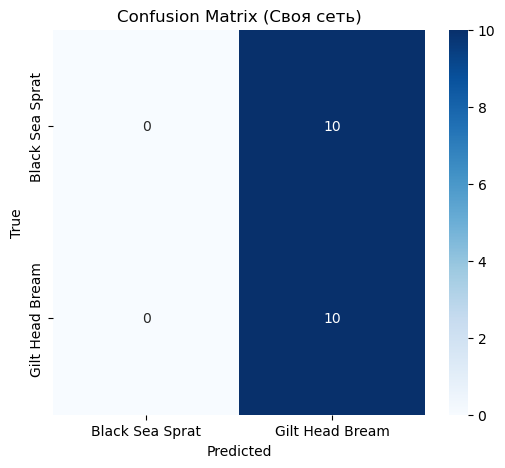

In [29]:
y_true = []
y_pred = []

for imgs, labels in test_ds:
    preds = model.predict(imgs, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(pred_classes)

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="weighted")

print(f"\nAccuracy: {acc:.4f}, F1 weighted: {f1:.4f}")
print(classification_report(y_true, y_pred, target_names=classes_list))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes_list,
            yticklabels=classes_list)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Своя сеть)")
plt.show()

In [33]:
##Нейросеть предсказывает только 2 класс


In [38]:
##Уровень 2 -используем модель ResNet18

In [39]:
class FishDatasetFromDF(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        unique_labels = sorted(df['target'].unique())
        self.label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
        self.idx_to_label = {idx: label for label, idx in self.label_to_idx.items()}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row['img']
        label_name = row['target']
        
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        
        label = self.label_to_idx[label_name]
        return img, label

In [40]:
from torch.utils.data import Dataset, DataLoader
train_transform = v2.Compose([
    v2.Resize((224, 224)), ##приводит все картинки к размеру 224×224 пикселя
    v2.RandomHorizontalFlip(p=0.5),## вероятностью 50% отражает картинку по горизонтали: неважно, плывёт рыба влево или вправо — класс тот же
    v2.RandomRotation(degrees=15),##поворачивает картинку на случайный угол в диапазоне ±15°
    v2.ColorJitter(
        brightness=0.2, ## немного меняет яркость и контраст. Ещё один способ аугментации, чтобы сеть не зависела от условий съёмки.  
        contrast=0.2,  
        saturation=0.15,  
        hue=0.05        
    ),
    v2.ToTensor(), 
##   v2.ToImage(),## гарантирует, что объект внутри пайплайна имеет правильный тип изображения  
##   v2.ToDtype(torch.float32, scale=True),##  конвертирует картинку в float32 и масштабирует значения пикселей из диапазона [0, 255] в [0.0, 1.0]. Без этого нормализация дальше не сработает корректно
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_transform = v2.Compose([
    v2.Resize((224, 224)),##нужен, чтобы размер совпадал с тем, что ожидает модель
##    v2.ToImage(),##приводит формат и масштаб пикселей к нужному виду.
##    v2.ToDtype(torch.float32, scale=True),
    v2.ToTensor(), 
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225])
])

C:\Users\User\anaconda3\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.5877128].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781574..2.2216995].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..1.6291069].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8267832..2.0822659].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Cli

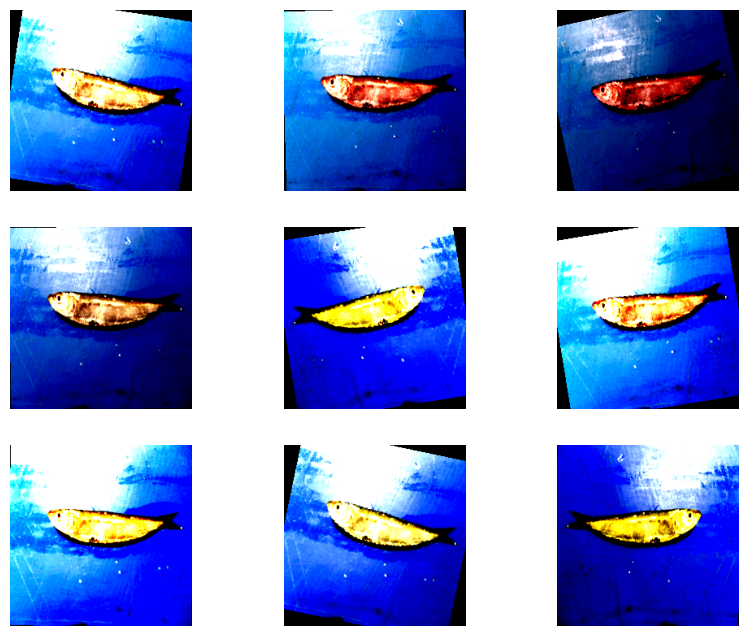

In [41]:
image = Image.open(df['img'].iloc[0])

sample_size = 9
fig, ax = plt.subplots(3, 3, figsize=(10, 8))
ax = ax.flatten()

for i in range(sample_size):
    augmented = train_transform(image)
    ax[i].imshow(augmented.permute(1, 2, 0))
    ax[i].axis('off')

plt.axis('off')
plt.show()

In [42]:

train_dataset = FishDatasetFromDF(train_df, transform=train_transform)
test_dataset  = FishDatasetFromDF(test_df,  transform=test_transform)

classes = train_dataset.idx_to_label
print("Классы:", classes)
print("Train size:", len(train_dataset))
print("Test size:",  len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)##берёт объекты Dataset и отдаёт данные батчами (по 32 картинки)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0)

Классы: {0: 'Black Sea Sprat', 1: 'Gilt Head Bream'}
Train size: 80
Test size: 20


In [43]:
import timm

img_size = 224
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") ##устройство для вычислений: CUDA-GPU ,

backbone_name = "resnet18" 
backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0)

with torch.no_grad():##Отключение вычисление градиентов — это нужно только для инференса (получения выхода сети), чтобы сэкономить память и ускорить вычисления
    dummy = torch.zeros(1, 3, img_size, img_size).to(device) ## «пустое» изображение-заглушка (размер батча: 1,3 канала (RGB))
    dummy_feat = backbone(dummy)##Прогоняем фиктивное изображение через backbone. На выходе получаем тензор признаков
    feature_dim = dummy_feat.shape[1] ## размерность признаков-нужно, чтобы правильно задать размер входного слоя MLP

mlp = nn.Sequential( ##классификатор (многослойный перцептрон) как последовательность слоёв
    nn.Linear(feature_dim, 256),##линейный слой: вход — размерность признаков, выход — 256 нейронов.
    nn.BatchNorm1d(256),## — пакетная нормализация по батчу для 256 признаков
    nn.ReLU(),##функция активации ReLU (--//)
    nn.Dropout(0.3),
    nn.Linear(256, len(classes)),##финальный линейный слой: выход равен числу классов
)

class TimmMLP(nn.Module):
    def __init__(self, backbone, mlp):
        super().__init__()
        self.backbone = backbone
        self.mlp = mlp

    def forward(self, x): ##Вход изображения подаётся на backbone, получаем признаки features.Признаки подаются на MLP, который возвращает финальные логиты по классам
        features = self.backbone(x)
        return self.mlp(features)

model = TimmMLP(backbone, mlp).to(device)
criterion = nn.CrossEntropyLoss()## Функция потерь для многоклассовой классификации
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [44]:
num_epochs = 10 ##Количество эпох

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0 ##Сброс счётчиков для текущей эпохи
    correct = 0
    total = 0

    for imgs, labels in train_loader: ##Перебор батчей (мини‑наборов) из DataLoader
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad() ##Обнуление градиентов. Иначе градиенты будут накапливаться от предыдущих батчей.
        outputs = model(imgs)
        loss = criterion(outputs, labels)## Вычисление функции потерь
        loss.backward()##Обратное распространение ошибки: вычисляются градиенты по весам модели.
        optimizer.step()##Обновление весов модели на основе посчитанных градиентов

        running_loss += loss.item() * imgs.size(0) ##Накопление потерь
        preds = outputs.argmax(dim=1)## предсказанные классы: для каждой картинки выбираем индекс с максимальным значением
        correct += (preds == labels).sum().item() ##число правильных предсказаний в батче и общее количество примеров
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")

Epoch 1/10 | Loss: 0.4983 | Acc: 0.7375
Epoch 2/10 | Loss: 0.0927 | Acc: 0.9875
Epoch 3/10 | Loss: 0.0570 | Acc: 1.0000
Epoch 4/10 | Loss: 0.0154 | Acc: 1.0000
Epoch 5/10 | Loss: 0.0177 | Acc: 1.0000
Epoch 6/10 | Loss: 0.0080 | Acc: 1.0000
Epoch 7/10 | Loss: 0.0094 | Acc: 1.0000
Epoch 8/10 | Loss: 0.0173 | Acc: 1.0000
Epoch 9/10 | Loss: 0.0046 | Acc: 1.0000
Epoch 10/10 | Loss: 0.0085 | Acc: 1.0000



Accuracy: 1.0000, F1 weighted: 1.0000
                 precision    recall  f1-score   support

Black Sea Sprat       1.00      1.00      1.00        10
Gilt Head Bream       1.00      1.00      1.00        10

       accuracy                           1.00        20
      macro avg       1.00      1.00      1.00        20
   weighted avg       1.00      1.00      1.00        20



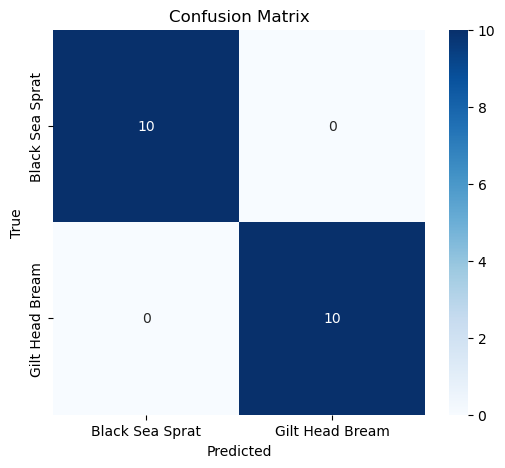

In [45]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        y_true.extend(labels.numpy())
        y_pred.extend(preds)

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="weighted")
print(f"\nAccuracy: {acc:.4f}, F1 weighted: {f1:.4f}")
print(classification_report(y_true, y_pred, target_names=[classes[i] for i in range(len(classes))]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[classes[i] for i in range(len(classes))],
            yticklabels=[classes[i] for i in range(len(classes))])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()